# Risk Prediction of Cardiovascular Disease

## Problem Statement:
To predict the risk of cardiovascular (heart) disease using machine learning techniques based on clinical and demographic data. The objective is to analyze relevant features such as age, blood pressure, cholesterol levels, BMI, lifestyle habits, and medical history, and build a model that can classify whether a person is at risk of heart disease or not.

## Importing necessary libraries

In [1]:
import sys
print(sys.executable)
print(sys.version)


C:\Users\madhu\miniconda3\python.exe
3.13.11 | packaged by Anaconda, Inc. | (main, Dec 10 2025, 21:21:58) [MSC v.1929 64 bit (AMD64)]


In [2]:
import sys
!{sys.executable} -m pip show statsmodels

Name: statsmodels
Version: 0.14.6
Summary: Statistical computations and models for Python
Home-page: https://www.statsmodels.org/
Author: 
Author-email: 
License: BSD License
Location: C:\Users\madhu\miniconda3\Lib\site-packages
Requires: numpy, packaging, pandas, patsy, scipy
Required-by: 


In [3]:
import sys
!{sys.executable} -m pip install statsmodels

In [4]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import joblib

## Import dataset

In [5]:
df = pd.read_csv('CVD_cleaned.csv')

##  Data Exploration

#### Check the dimensions (number of rows and columns) to get an overview of the data structure

In [6]:
df

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poo,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,m,25-29,168,81.65,29.05,No,4,30,8,0
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,65-69,180,69.85,21.48,No,8,15,60,4
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,157,61.23,24.69,Yes,4,40,8,4
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,65-69,183,79.38,23.73,No,3,30,12,0


In [7]:
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poo,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0


In [8]:
df.tail()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,m,25-29,168,81.65,29.05,No,4,30,8,0
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,65-69,180,69.85,21.48,No,8,15,60,4
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,157,61.23,24.69,Yes,4,40,8,4
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,65-69,183,79.38,23.73,No,3,30,12,0
308853,Excellent,Within the past year,Yes,No,No,No,No,No,No,Female,45-49,160,81.19,31.71,No,1,5,12,1


In [9]:
print(df.shape)
df.info()

(308854, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  int64  
 12  Weight_(kg)                   3

#### The dataset has 308854 entries and 19 columns, with 12 categorical and 7 numerical features. Most columns have 308854 non-null values, with minimal missing data. The data types include float64, int64 for numerical columns and object for categorical ones, with a memory usage of 44+ MB.

In [10]:
print(df.describe())
df.describe(include=object)

         Height_(cm)    Weight_(kg)            BMI  Alcohol_Consumption  \
count  308854.000000  308854.000000  308854.000000        308854.000000   
mean      170.615249      83.588655      28.626211             5.096366   
std        10.658026      21.343210       6.522323             8.199763   
min        91.000000      24.950000      12.020000             0.000000   
25%       163.000000      68.040000      24.210000             0.000000   
50%       170.000000      81.650000      27.440000             1.000000   
75%       178.000000      95.250000      31.850000             6.000000   
max       241.000000     293.020000      99.330000            30.000000   

       Fruit_Consumption  Green_Vegetables_Consumption  \
count      308854.000000                 308854.000000   
mean           29.835200                     15.110441   
std            24.875735                     14.926238   
min             0.000000                      0.000000   
25%            12.000000          

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Smoking_History
count,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854
unique,7,5,2,2,2,2,2,4,2,5,13,2
top,Very Good,Within the past year,Yes,No,No,No,No,No,No,Female,65-69,No
freq,110395,239371,239381,283883,278860,278976,246953,259141,207783,160186,33434,183590


#### The dataset includes numerical features with average height (170.7 cm), weight (83.6 kg), and BMI (28.6), with wide ranges in consumption variables. Categorical features show that "Very Good" is the most common general health status, "Within the past year" is the most frequent checkup, and "No" is predominant for health conditions like heart disease. "Female" is the most common sex, and "65-69" is the most frequent age category. Most individuals report no smoking history.

In [11]:
for i in df.columns:
    print("unique in",i,':',df[i].unique())

unique in General_Health : ['Poo' 'Very Good' 'Poor' 'Good' 'Fair' 'Excellent' 'poo']
unique in Checkup : ['Within the past 2 years' 'Within the past year' '5 or more years ago'
 'Within the past 5 years' 'Never']
unique in Exercise : ['No' 'Yes']
unique in Heart_Disease : ['No' 'Yes']
unique in Skin_Cancer : ['No' 'Yes']
unique in Other_Cancer : ['No' 'Yes']
unique in Depression : ['No' 'Yes']
unique in Diabetes : ['No' 'Yes' 'No, pre-diabetes or borderline diabetes'
 'Yes, but female told only during pregnancy']
unique in Arthritis : ['Yes' 'No']
unique in Sex : ['Female' 'Male' 'F' 'M' 'm']
unique in Age_Category : ['70-74' '60-64' '75-79' '80+' '65-69' '50-54' '45-49' '18-24' '30-34'
 '55-59' '35-39' '40-44' '25-29']
unique in Height_(cm) : [150 165 163 180 191 183 175 160 168 178 152 157 188 185 170 173 155 193
 196 206 198 140 135 145 147 142 201 218 124 203 137 122 216 224 229 151
 177 164 162 156 153 169 167 172 106 190 143 171 154 176 200 146 148 158
 159 187 104 120 107 211 2

In [12]:
df['General_Health'] = df['General_Health'].replace('Poo', 'Poor')

#### The code replaces the value 'Poo' with 'Poor' in the 'General_Health' column, correcting a possible typo.

In [13]:
df['General_Health'] = pd.Categorical(df['General_Health'],
    categories=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'], ordered=True)

df['Checkup'] = pd.Categorical(df['Checkup'],
    categories=['Never', '5 or more years ago', 'Within the past 5 years',
                'Within the past 2 years', 'Within the past year'], ordered=True)

df['Age_Category'] = pd.Categorical(df['Age_Category'],
    categories=['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54',
                '55-59', '60-64', '65-69', '70-74', '75-79', '80+'], ordered=True)

# Sort the DataFrame based on these logical categorical columns
df = df.sort_values(by=['General_Health', 'Checkup', 'Age_Category'])

# Optional: Display sorted unique values for all categorical columns
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"{col}: {sorted(df[col].dropna().unique())}")

Exercise: ['No', 'Yes']
Heart_Disease: ['No', 'Yes']
Skin_Cancer: ['No', 'Yes']
Other_Cancer: ['No', 'Yes']
Depression: ['No', 'Yes']
Diabetes: ['No', 'No, pre-diabetes or borderline diabetes', 'Yes', 'Yes, but female told only during pregnancy']
Arthritis: ['No', 'Yes']
Sex: ['F', 'Female', 'M', 'Male', 'm']
Smoking_History: ['No', 'Yes']


#### The code orders and sorts categorical columns (General_Health, Checkup, Age_Category), displays sorted unique values for them, and checks for missing values in the DataFrame, confirming the presence of NaN values.

In [14]:
print(df['Sex'].value_counts())

Sex
Female    160186
Male      148652
F             10
M              5
m              1
Name: count, dtype: int64


In [15]:
df['Sex'] = df['Sex'].replace({
    'm': 'Male',
    'M': 'Male',
    'f': 'Female',
    'F': 'Female'
})

In [16]:
print(df['Sex'].value_counts())

Sex
Female    160196
Male      148658
Name: count, dtype: int64


In [17]:
print(df.isnull().values.any())

True


#### The statement df.isnull().values.any() returns True, indicating that there are still missing (null) values in the DataFrame.

In [18]:
print(df.isnull().sum())

General_Health                  4
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64


In [19]:
df = df.dropna()

In [20]:
numerical_cols = ['Height_(cm)', 'Weight_(kg)', 'BMI',
                  'Alcohol_Consumption', 'Fruit_Consumption',
                  'Green_Vegetables_Consumption', 'FriedPotato_Consumption']

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [21]:
df.duplicated().sum()

np.int64(80)

In [22]:
df = df.drop_duplicates()

In [23]:
df.duplicated().sum()

np.int64(0)

#### The code checks for duplicate rows in the DataFrame and returns 0, indicating there are no duplicate rows in the dataset.

In [24]:
df.reset_index(drop=True,inplace=True)

In [25]:
df

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Never,Yes,No,No,No,Yes,No,No,Male,18-24,178,76.66,24.25,Yes,0,30,30,30
1,Poor,Never,No,No,No,No,Yes,No,No,Female,18-24,160,69.85,27.28,No,1,0,0,8
2,Poor,Never,Yes,No,No,No,Yes,"No, pre-diabetes or borderline diabetes",Yes,Male,18-24,185,142.88,41.56,No,0,30,1,8
3,Poor,Never,Yes,No,No,No,No,No,No,Male,18-24,188,99.79,28.25,No,2,60,10,8
4,Poor,Never,Yes,No,No,No,Yes,No,No,Male,25-29,193,136.08,36.52,No,0,30,30,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308765,Excellent,Within the past year,Yes,No,No,No,No,No,No,Female,80+,152,56.70,24.41,No,0,60,60,0
308766,Excellent,Within the past year,Yes,No,No,No,No,No,No,Female,80+,157,62.60,25.24,No,2,30,0,0
308767,Excellent,Within the past year,Yes,No,No,No,No,"No, pre-diabetes or borderline diabetes",No,Male,80+,178,89.81,28.41,No,0,30,12,4
308768,Excellent,Within the past year,Yes,No,No,No,No,No,No,Male,80+,170,56.70,19.58,No,1,30,12,1


#### The command df.reset_index(drop=True, inplace=True) resets the index of the DataFrame, removing the old index and starting fresh with a default integer index. The DataFrame is now reindexed with the previous rows intact, but with a new continuous index.

# Performing Visualization
* Helps understand the data distribution, relationships, and trends.
* Assists in identifying outliers, missing values, and correlations.

## Univariate Analysis
* Analysis of a single variable to understand its distribution and characteristics.

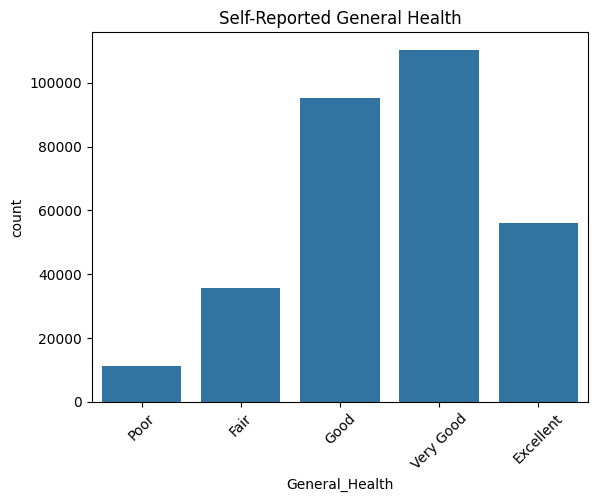

In [26]:
sns.countplot(x='General_Health', data=df, order=df['General_Health'].cat.categories)
plt.title("Self-Reported General Health")
plt.xticks(rotation=45)
plt.show()

#### The bar plot shows that most people rate their general health as "Very Good" or "Good," with fewer reporting "Excellent," and the least reporting "Fair" or "Poor." This indicates a generally positive perception of health among respondents, though the lower representation of "Poor" and "Fair" suggests potential class imbalance that may need attention in analysis or modeling.

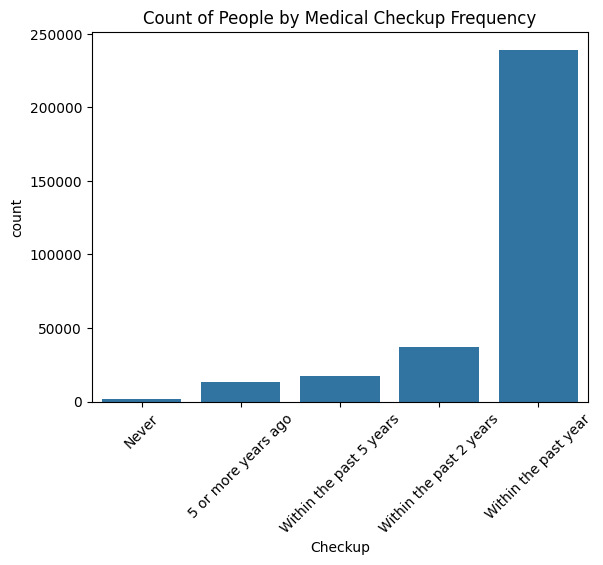

In [27]:
sns.countplot(x='Checkup', data=df, order=df['Checkup'].cat.categories)
plt.xticks(rotation=45)
plt.title("Count of People by Medical Checkup Frequency")
plt.show()

#### The chart shows that most people had a health check-up within the past year, indicating good health awareness. Very few delayed check-ups beyond five years or never had one, suggesting that only a small portion of the population neglects regular medical care.

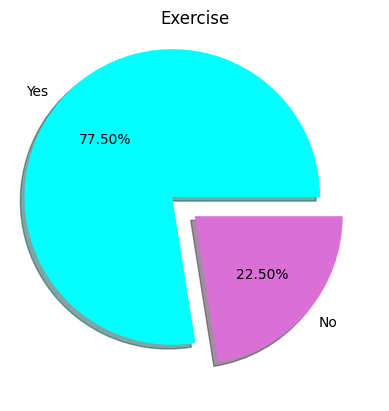

In [28]:
values = df.Exercise.value_counts().values
labels = df.Exercise.value_counts().keys()
explode = (0.2,0)

plt.pie(values,labels=labels,explode=explode,shadow=True,autopct='%1.2f%%',colors=['aqua','orchid'])
plt.title('Exercise')
plt.show()

#### The Exercise chart indicates that 77.50% of individuals in the dataset engage in regular physical activity, while 22.50% do not. This suggests that a large majority maintain an active lifestyle, which could have positive implications for overall health.

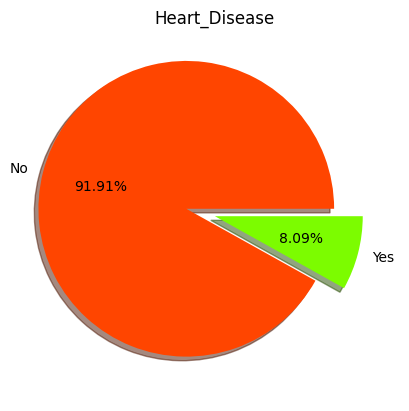

In [29]:
values = df.Heart_Disease.value_counts().values
labels = df.Heart_Disease.value_counts().keys()
explode = (0.2,0)

plt.pie(values,labels=labels,explode=explode,shadow=True,autopct='%1.2f%%',colors=['orangered','lawngreen'])
plt.title('Heart_Disease')
plt.show()

#### The Heart Disease chart shows that 91.91% of individuals do not have heart disease, while 8.09% have been diagnosed with it. This reveals that heart disease affects a small proportion of the population in the dataset.

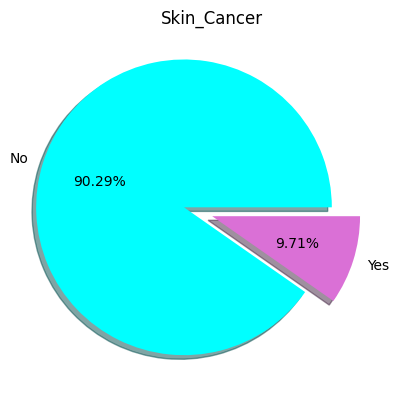

In [30]:
values = df.Skin_Cancer.value_counts().values
labels = df.Skin_Cancer.value_counts().keys()
explode = (0.2,0)

plt.pie(values,labels=labels,explode=explode,shadow=True,autopct='%1.2f%%',colors=['aqua','orchid'])
plt.title('Skin_Cancer')
plt.show()

#### The Skin Cancer chart reveals that 90.29% of individuals in the dataset have not been diagnosed with skin cancer, while 9.71% have. This indicates that skin cancer affects a relatively small portion of the population.

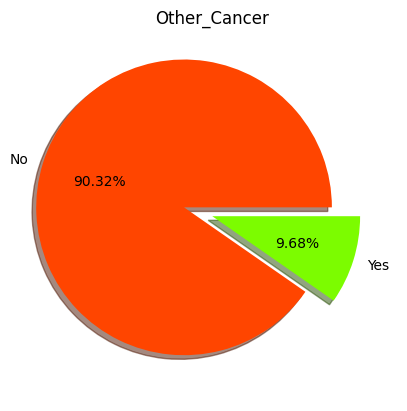

In [31]:
values = df.Other_Cancer.value_counts().values
labels = df.Other_Cancer.value_counts().keys()
explode = (0.2,0)

plt.pie(values,labels=labels,explode=explode,shadow=True,autopct='%1.2f%%',colors=['orangered','lawngreen'])
plt.title('Other_Cancer')
plt.show()

#### The Other Cancer chart shows that 90.32% of individuals have no history of other forms of cancer, while 9.68% do. Similar to skin cancer, this suggests that the incidence of other cancers is low within this dataset.

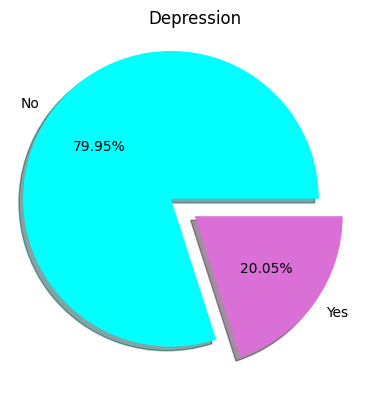

In [32]:
values = df.Depression.value_counts().values
labels = df.Depression.value_counts().keys()
explode = (0.2,0)

plt.pie(values,labels=labels,explode=explode,shadow=True,autopct='%1.2f%%',colors=['aqua','orchid'])
plt.title('Depression')
plt.show()

#### The Depression chart shows that 79.95% of individuals in the dataset have not experienced depression, while 20.05% have. This indicates that while a majority of the population reports no history of depression, a notable portion—around one in five—has experienced it.

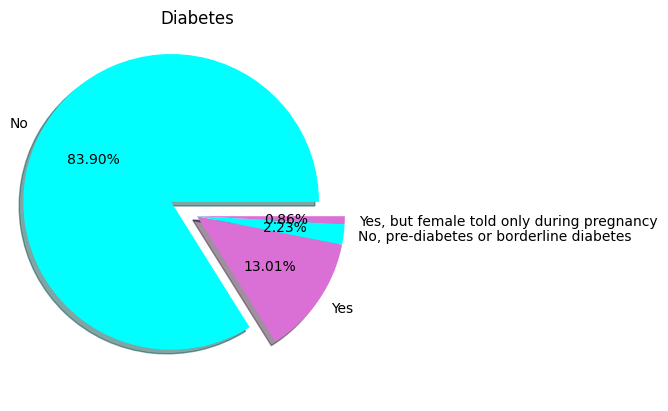

In [33]:
values = df['Diabetes'].value_counts().values
labels = df['Diabetes'].value_counts().keys()
explode = [0.2] + [0] * (len(labels) - 1)

plt.pie(values, labels=labels, explode=explode,shadow=True,autopct='%1.2f%%', colors=['aqua','orchid']) 
plt.title('Diabetes')
plt.show()

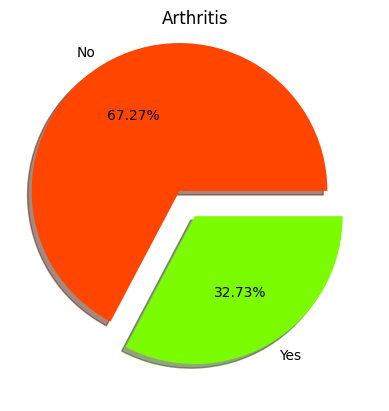

In [34]:
values = df.Arthritis.value_counts().values
labels = df.Arthritis.value_counts().keys()
explode = (0.2,0)

plt.pie(values,labels=labels,explode=explode,shadow=True,autopct='%1.2f%%',colors=['orangered','lawngreen'])
plt.title('Arthritis')
plt.show()

#### The Arthritis chart illustrates that 67.27% of individuals do not suffer from arthritis, whereas 32.73% do. This means nearly one-third of the population has arthritis, suggesting it is a relatively common condition among the individuals in the dataset.

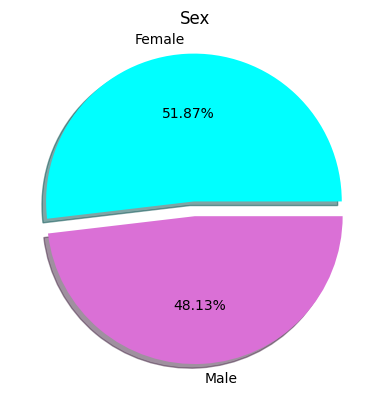

In [35]:
values = df.Sex.value_counts().values
labels = df.Sex.value_counts().keys()
explode = (0.1,0)
plt.pie(values,labels=labels,explode=explode,shadow=True,autopct='%1.2f%%',colors=['aqua','orchid'])
plt.title('Sex')
plt.show()

#### The Sex Distribution chart shows that the dataset has a fairly balanced gender composition, with 51.87% females and 48.13% males. Although the difference is small, females make up a slightly larger portion of the population.

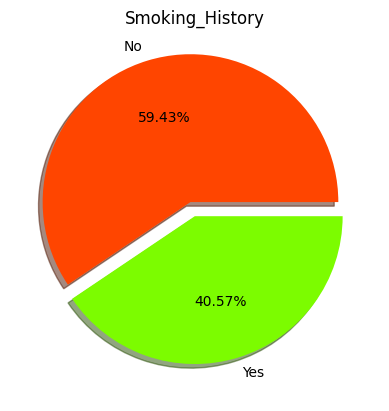

In [36]:
values = df.Smoking_History.value_counts().values
labels = df.Smoking_History.value_counts().keys()
explode = (0.1,0)

plt.pie(values,labels=labels,explode=explode,shadow=True,autopct='%1.2f%%',colors=['orangered','lawngreen'])
plt.title('Smoking_History')
plt.show()

#### The Smoking History chart reveals that 59.43% of individuals have no history of smoking, while 40.57% do have a smoking history. This indicates that the majority of the population are non-smokers, but a considerable portion has engaged in smoking.

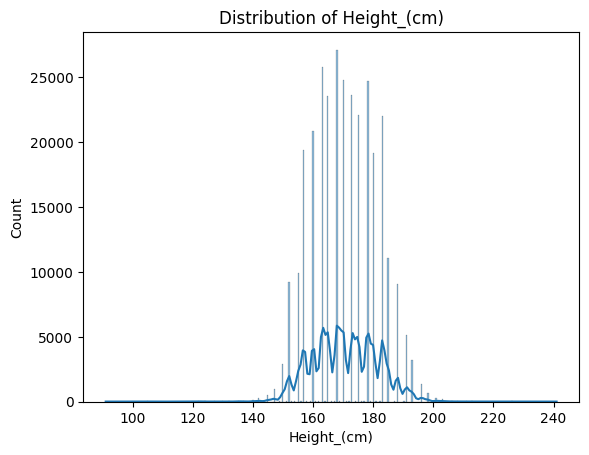

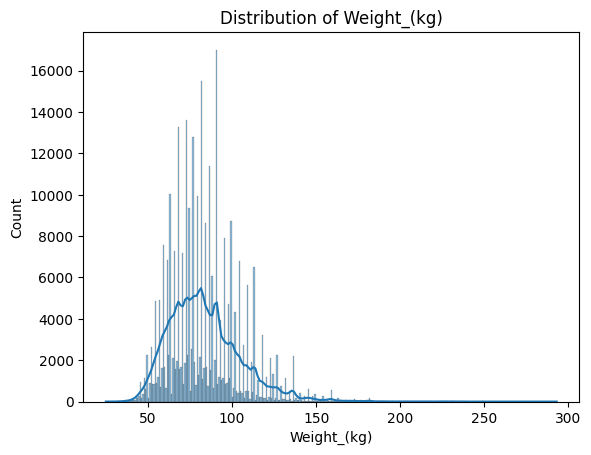

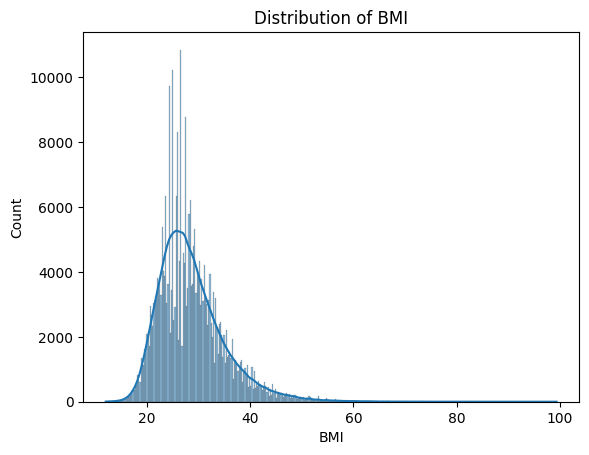

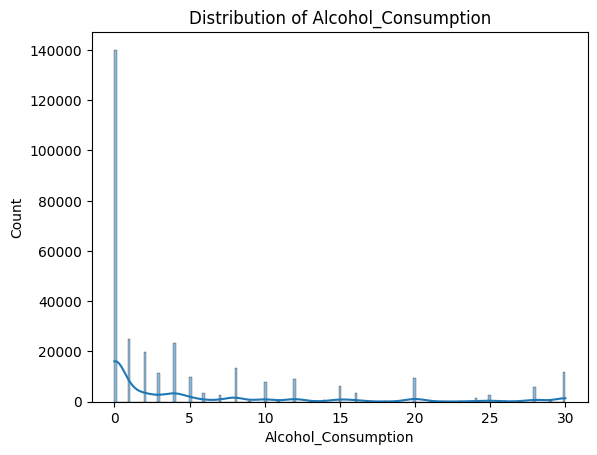

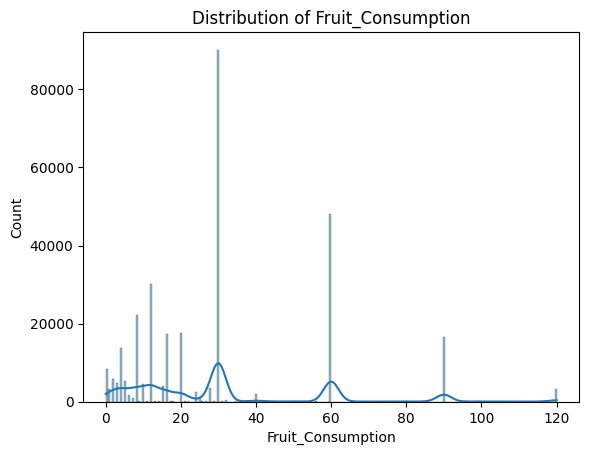

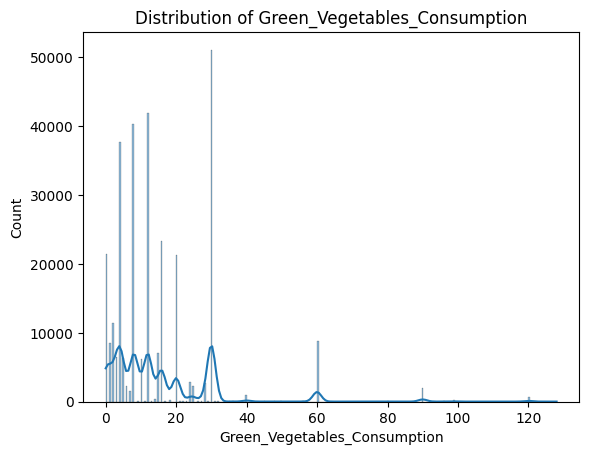

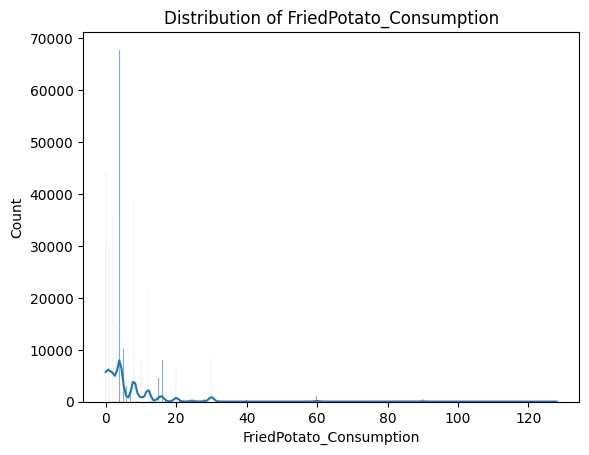

In [37]:
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

#### Most individuals fall within normal or moderate ranges for health metrics, but all consumption-related features are right-skewed, indicating that high consumers are rare and zero or low consumption is common.
 * Height and Weight: Height follows a near-normal distribution, while weight is right-skewed with a peak around 70–80 kg, indicating a       common average range but with some heavier outliers.

 * BMI: BMI is also right-skewed, with most values between 20 and 30, suggesting a majority fall into the normal to overweight range.

 * Alcohol Consumption: Most people report low or zero alcohol intake, with a sharp decline as consumption increases.

 * Fruit, Vegetable, and Fried Potato Consumption: These are highly right-skewed with clear peaks at certain values (e.g., 20, 30, 60), which may reflect common reporting habits or dietary patterns. The majority consume lower quantities, with a few outliers consuming very high amounts.

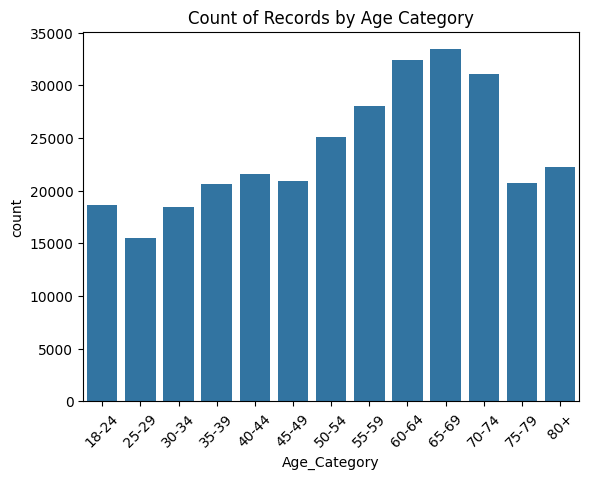

In [38]:
sns.countplot(x='Age_Category', data=df, order=df['Age_Category'].cat.categories)
plt.xticks(rotation=45)
plt.title("Count of Records by Age Category")
plt.show()

#### The chart shows the age distribution of a population, with the largest group aged 65–69. The number of individuals generally increases with age up to 65–69, then declines in older age groups. Younger age groups like 18–24 and 25–29 have fewer individuals, suggesting the dataset likely represents an older population.

## Bivariate Analysis
* Explores the relationship between two variables to identify patterns, correlations, or associations.

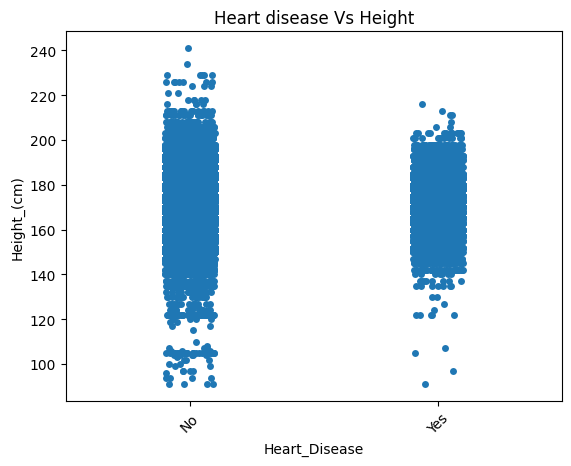

In [39]:
sns.stripplot(x='Heart_Disease', y='Height_(cm)', data=df, jitter=True)

plt.xticks(rotation=45)
plt.title('Heart disease Vs Height')
plt.show()

#### The plot shows that height distribution is similar for individuals with and without heart disease, suggesting that height does not have a significant influence on heart disease risk.

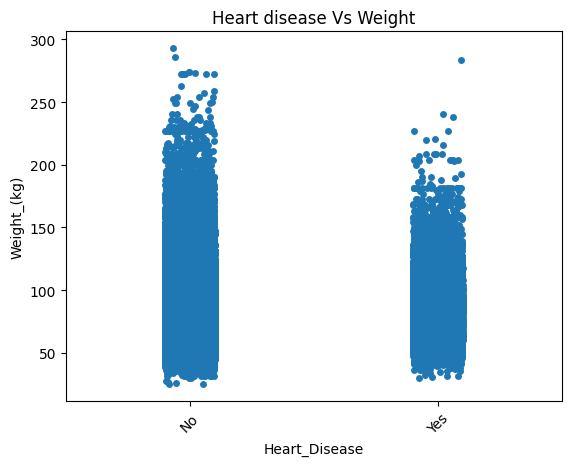

In [40]:
sns.stripplot(x='Heart_Disease', y='Weight_(kg)', data=df, jitter=True)

plt.xticks(rotation=45)
plt.title('Heart disease Vs Weight')
plt.show()

#### The plot shows that the weight distribution is fairly similar between individuals with and without heart disease, but those with heart disease tend to have slightly higher weights on average. This suggests that higher body weight may be associated with an increased risk of heart disease.

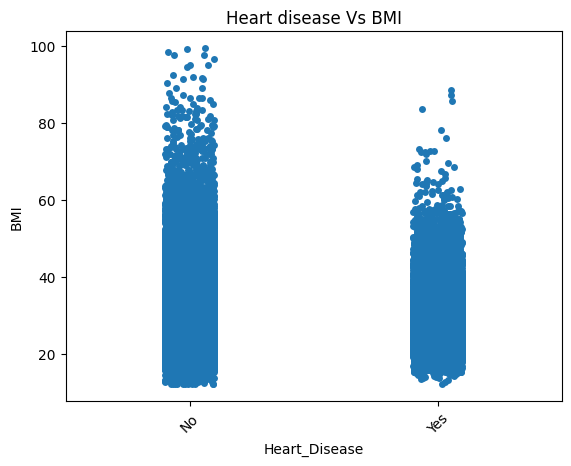

In [41]:
sns.stripplot(x='Heart_Disease', y='BMI', data=df, jitter=True)

plt.xticks(rotation=45)
plt.title('Heart disease Vs BMI')
plt.show()

#### The strip plot shows the distribution of BMI for individuals with and without heart disease. Both groups have a wide BMI range, with no clear visual difference, suggesting further analysis is needed to determine any significant relationship.

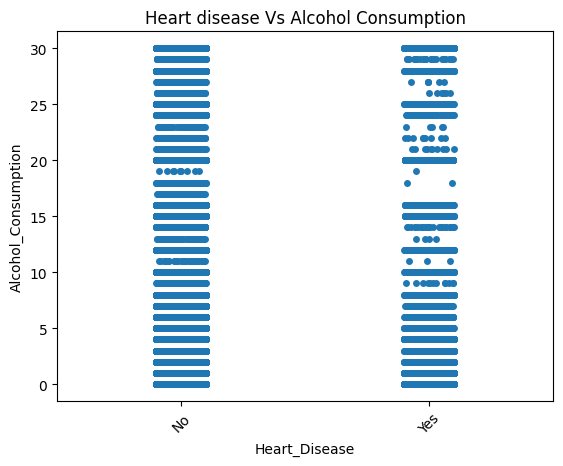

In [42]:
sns.stripplot(x='Heart_Disease', y='Alcohol_Consumption', data=df, jitter=True)

plt.xticks(rotation=45)
plt.title('Heart disease Vs Alcohol Consumption')
plt.show()

#### The plot shows that alcohol consumption levels are similarly distributed among individuals with and without heart disease, suggesting no clear visual correlation.

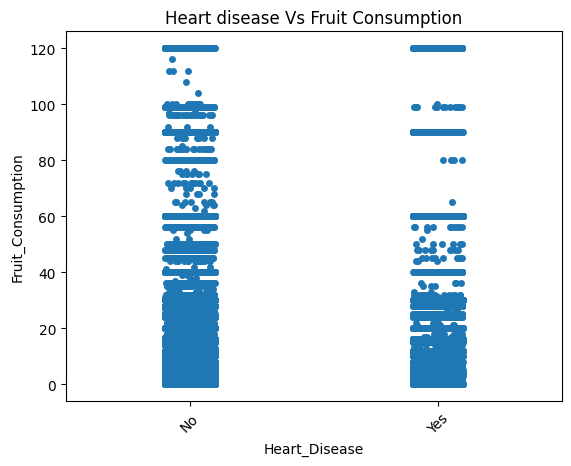

In [43]:
sns.stripplot(x='Heart_Disease', y='Fruit_Consumption', data=df, jitter=True)

plt.xticks(rotation=45)
plt.title('Heart disease Vs Fruit Consumption')
plt.show()

#### This plot shows fruit consumption among people with and without heart disease. Both groups have a wide and similar range, indicating no clear visual difference in fruit consumption based on heart disease status.

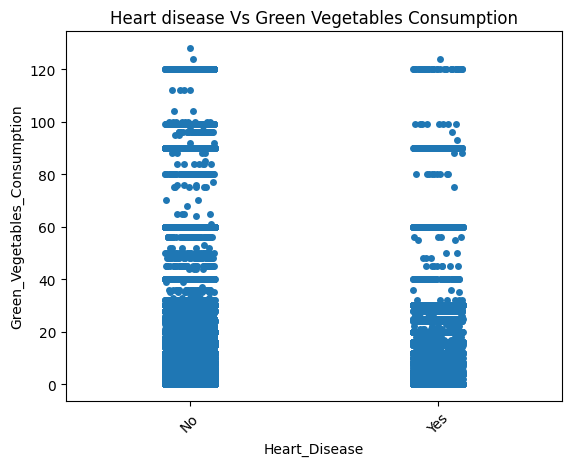

In [44]:
sns.stripplot(x='Heart_Disease', y='Green_Vegetables_Consumption', data=df, jitter=True)

plt.xticks(rotation=45)
plt.title('Heart disease Vs Green Vegetables Consumption')
plt.show()

#### The plot compares green vegetable consumption between people with and without heart disease. Both groups show a wide and overlapping range, indicating no strong visible difference in consumption patterns related to heart disease.

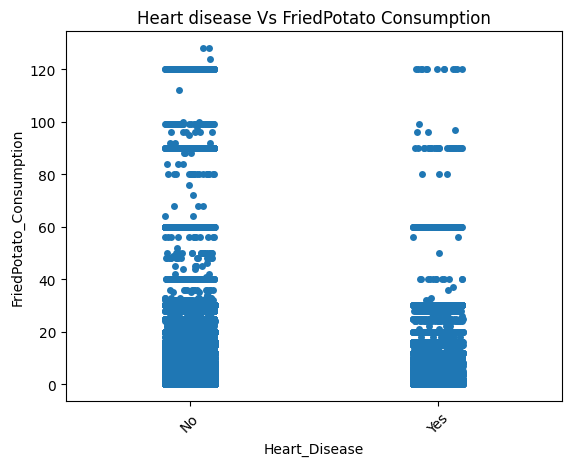

In [45]:
sns.stripplot(x='Heart_Disease', y='FriedPotato_Consumption', data=df, jitter=True)

plt.xticks(rotation=45)
plt.title('Heart disease Vs FriedPotato Consumption')
plt.show()

#### The plot shows fried potato consumption among individuals with and without heart disease. Both groups have similar spread and density, indicating no clear visual link between fried potato consumption and heart disease presence.

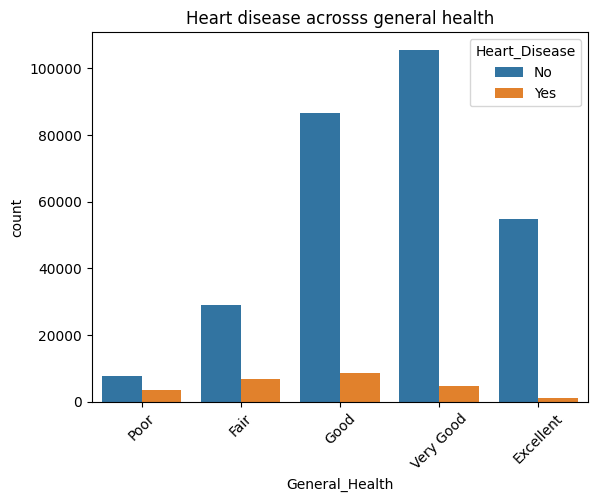

In [46]:
sns.countplot(x='General_Health', hue='Heart_Disease', data=df)
plt.xticks(rotation=45)
plt.title("Heart disease acrosss general health")
plt.show()

#### This plot shows the relationship between general health and heart disease. As general health improves from "Poor" to "Excellent," the number of people with heart disease (blue bars) decreases noticeably. This suggests that poorer self-rated health is associated with a higher likelihood of heart disease.

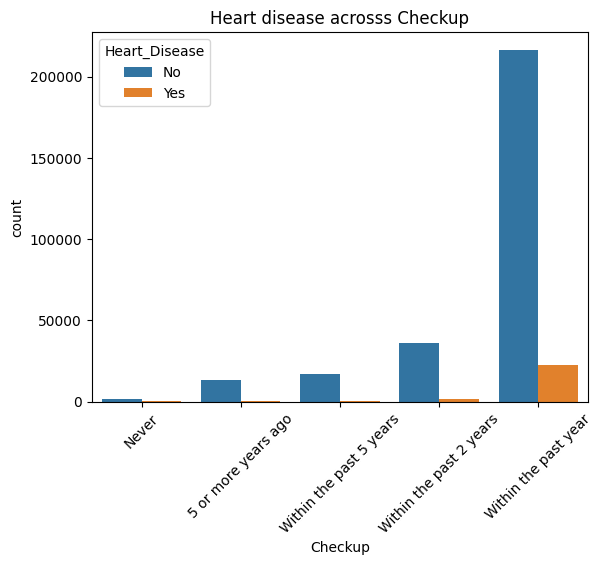

In [47]:
sns.countplot(x='Checkup', hue='Heart_Disease', data=df)
plt.xticks(rotation=45)
plt.title("Heart disease acrosss Checkup")
plt.show()

#### The plot suggests that people with heart disease tend to have more recent checkups, with the highest number of heart disease cases among those who visited a doctor in the past year. This may indicate that regular checkups help detect heart disease early.

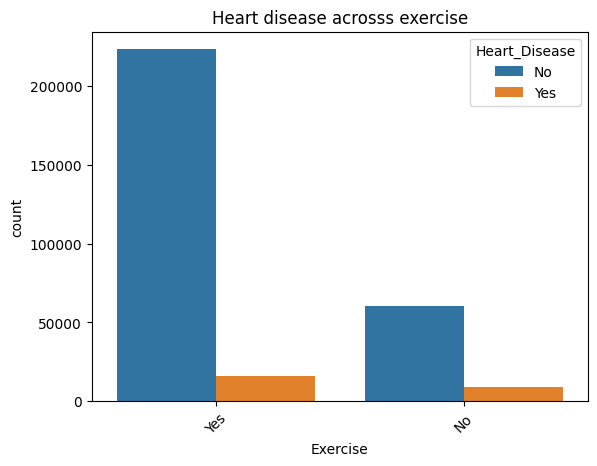

In [48]:
sns.countplot(x='Exercise', hue='Heart_Disease', data=df)
plt.xticks(rotation=45)
plt.title("Heart disease acrosss exercise")
plt.show()

#### People who exercise are significantly less likely to have heart disease compared to those who don’t. The chart shows a much higher count of heart disease among non-exercisers, suggesting a strong association between regular exercise and heart health.

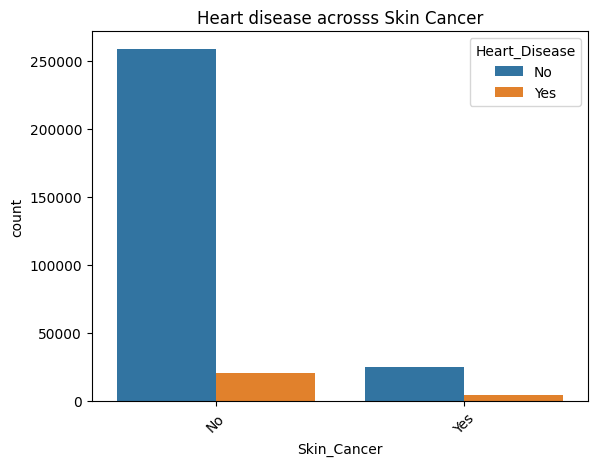

In [49]:
sns.countplot(x='Skin_Cancer', hue='Heart_Disease', data=df)
plt.xticks(rotation=45)
plt.title("Heart disease acrosss Skin Cancer")
plt.show()

#### People with skin cancer appear to have a slightly higher proportion of heart disease compared to those without skin cancer. However, the overall number of cases is much lower, so the association is weak based on this plot alone.

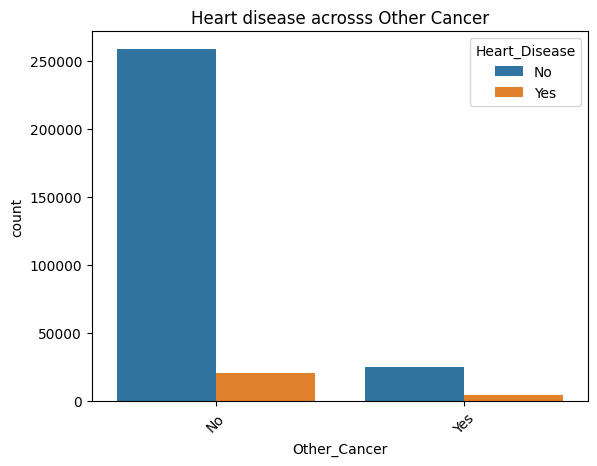

In [50]:
sns.countplot(x='Other_Cancer', hue='Heart_Disease', data=df)
plt.xticks(rotation=45)
plt.title("Heart disease acrosss Other Cancer")
plt.show()

#### People with other types of cancer have a slightly higher proportion of heart disease compared to those without. However, like with skin cancer, the overall number of individuals with both heart disease and other cancer is relatively low, suggesting only a weak association.

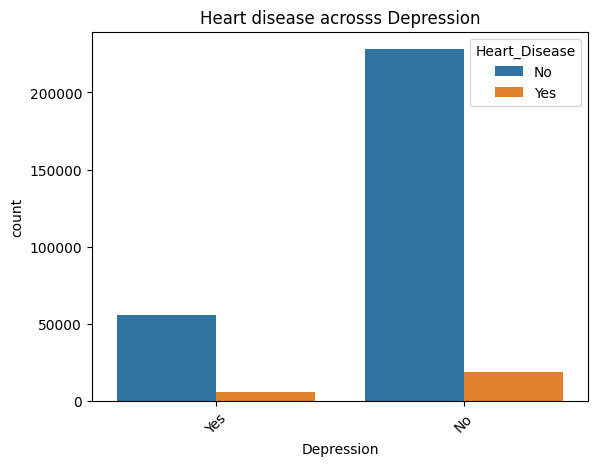

In [51]:
sns.countplot(x='Depression', hue='Heart_Disease', data=df)
plt.xticks(rotation=45)
plt.title("Heart disease acrosss Depression")
plt.show()

#### People with depression show a higher proportion of heart disease compared to those without depression. Although most individuals (depressed or not) do not have heart disease, the rate of heart disease is noticeably higher among those with depression, suggesting a stronger possible link between depression and heart disease than seen in previous plots.

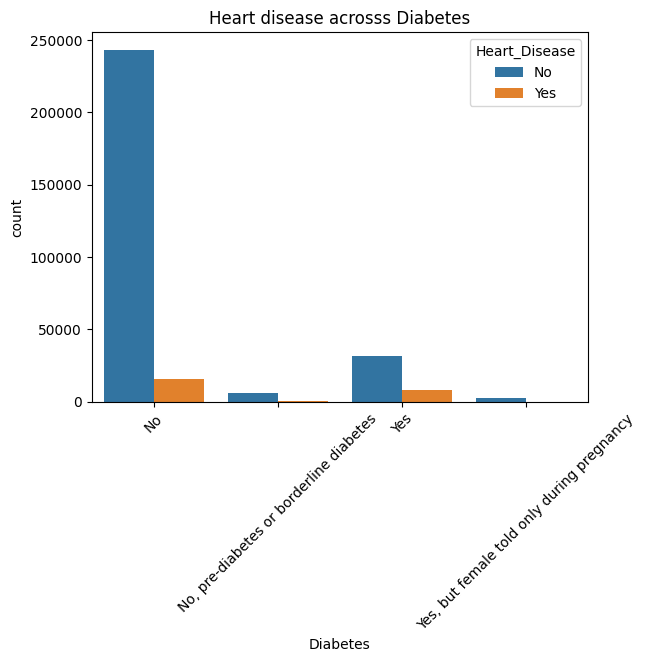

In [52]:
sns.countplot(x='Diabetes', hue='Heart_Disease', data=df)
plt.xticks(rotation=45)
plt.title("Heart disease acrosss Diabetes")
plt.show()

#### People with diabetes—especially those with a clear diagnosis (“Yes”)—have a higher proportion of heart disease compared to those without diabetes. The trend is evident across other diabetes-related categories too (like borderline diabetes), though to a lesser extent.There appears to be a strong association between diabetes and heart disease, making diabetes a significant risk factor.

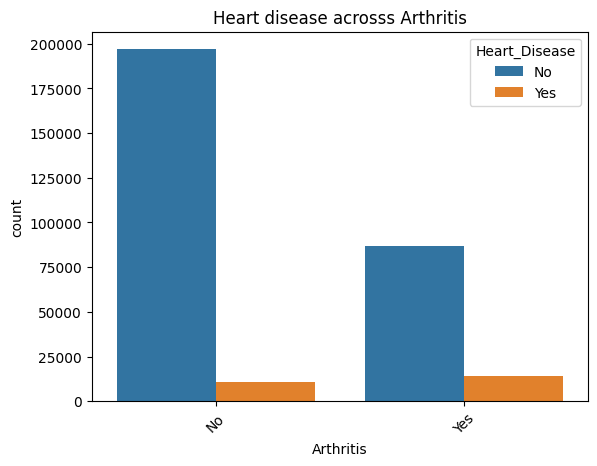

In [53]:
sns.countplot(x='Arthritis', hue='Heart_Disease', data=df)
plt.xticks(rotation=45)
plt.title("Heart disease acrosss Arthritis")
plt.show()

#### People with arthritis show a higher proportion of heart disease compared to those without it, suggesting a possible link between the two conditions.

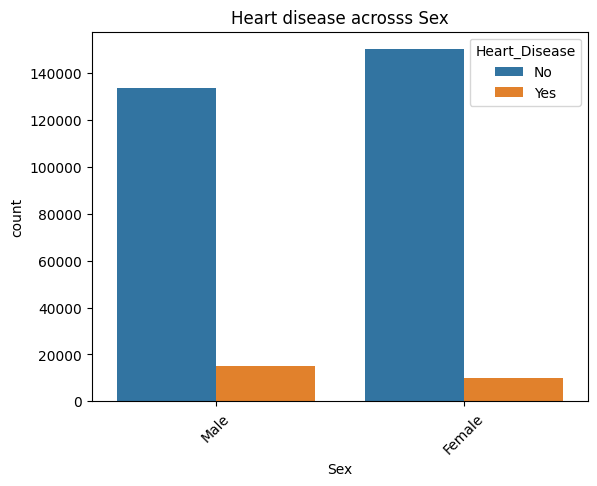

In [54]:
sns.countplot(x='Sex', hue='Heart_Disease', data=df)
plt.xticks(rotation=45)
plt.title("Heart disease acrosss Sex")
plt.show()

#### The chart shows that most people, both male and female, do not have heart disease. However, heart disease is slightly more common in males than in females.

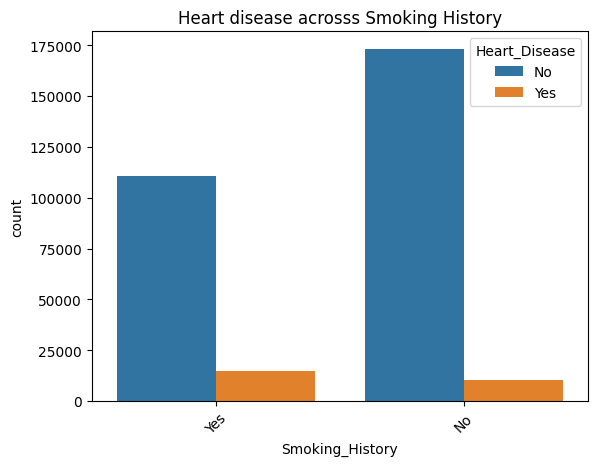

In [55]:
sns.countplot(x='Smoking_History', hue='Heart_Disease', data=df)
plt.xticks(rotation=45)
plt.title("Heart disease acrosss Smoking History")
plt.show()

#### People who have smoked are more likely to have heart disease compared to those who haven’t, even though there are more non-smokers overall.

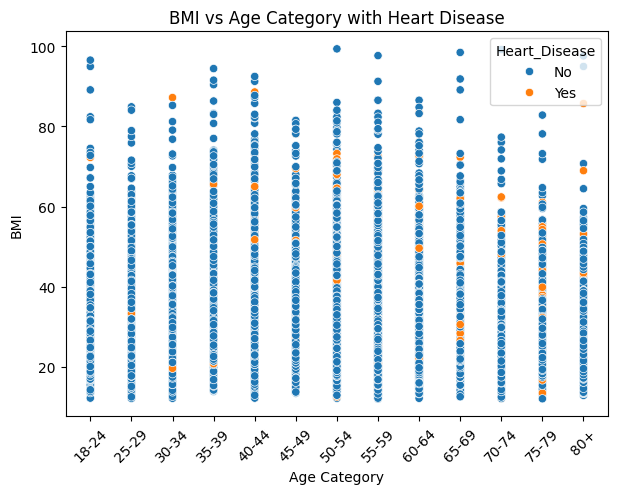

In [56]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Age_Category', y='BMI', hue='Heart_Disease')
plt.title('BMI vs Age Category with Heart Disease')
plt.xlabel('Age Category')
plt.ylabel('BMI')
plt.xticks(rotation=45)
plt.show()

#### The scatter plot shows the relationship between BMI and age categories, highlighting heart disease presence. Blue dots (heart disease) appear more in middle-aged and older groups (45+), while BMI varies widely across all ages. Although higher BMI is common in both groups, there's a slight clustering of heart disease cases in the moderate to high BMI range. Overall, no strong direct correlation is evident.

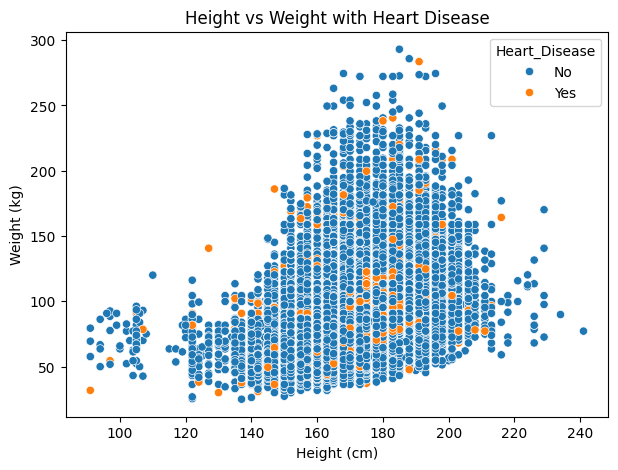

In [57]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Height_(cm)', y='Weight_(kg)', hue='Heart_Disease')
plt.title('Height vs Weight with Heart Disease')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

#### The scatter plot shows the relationship between height and weight, categorized by heart disease status. Most individuals fall within the mid-range of height (145–190 cm) and weight (50–150 kg). Orange dots (no heart disease) dominate, while blue dots (heart disease) are fewer. There is no clear separation between the two groups, suggesting height and weight alone may not strongly indicate heart disease.

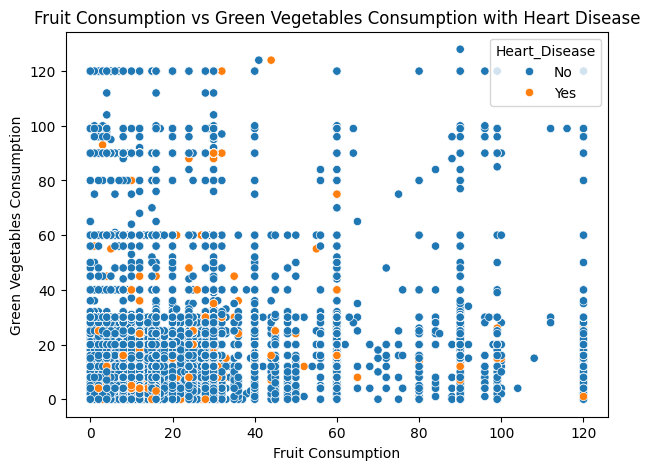

In [58]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Fruit_Consumption', y='Green_Vegetables_Consumption', hue='Heart_Disease')
plt.title('Fruit Consumption vs Green Vegetables Consumption with Heart Disease')
plt.xlabel('Fruit Consumption')
plt.ylabel('Green Vegetables Consumption')
plt.show()

#### The plot shows that most individuals without heart disease have low to moderate fruit and vegetable intake, while those with heart disease are fewer and scattered, suggesting weak correlation between diet and heart disease.

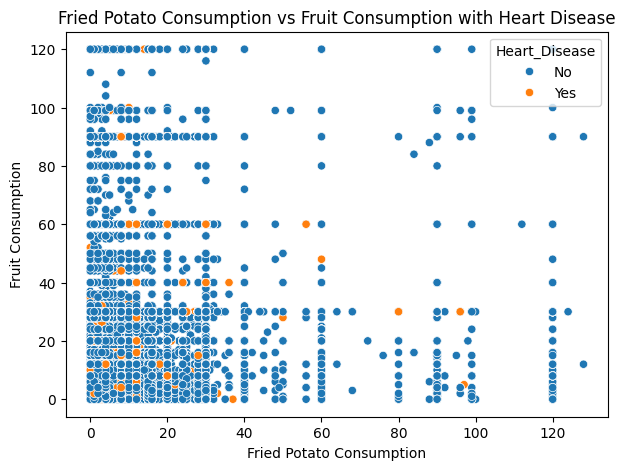

In [59]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='FriedPotato_Consumption', y='Fruit_Consumption', hue='Heart_Disease')
plt.title('Fried Potato Consumption vs Fruit Consumption with Heart Disease')
plt.xlabel('Fried Potato Consumption')
plt.ylabel('Fruit Consumption')
plt.show()

#### Most people consume low to moderate fried potatoes and fruits, with few heart disease cases scattered, showing little correlation with these foods.

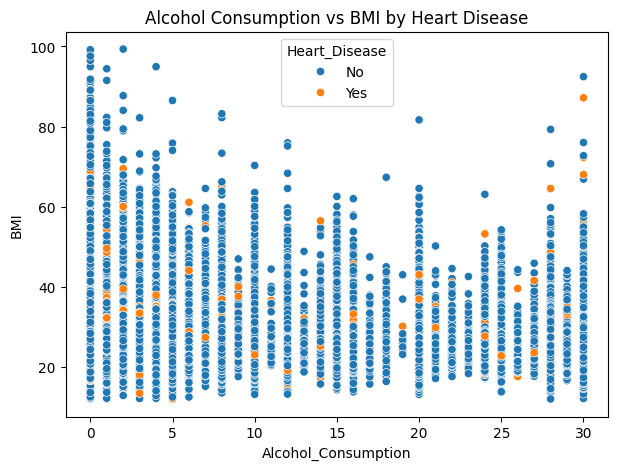

In [60]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Alcohol_Consumption', y='BMI', hue='Heart_Disease')
plt.title('Alcohol Consumption vs BMI by Heart Disease')
plt.show()

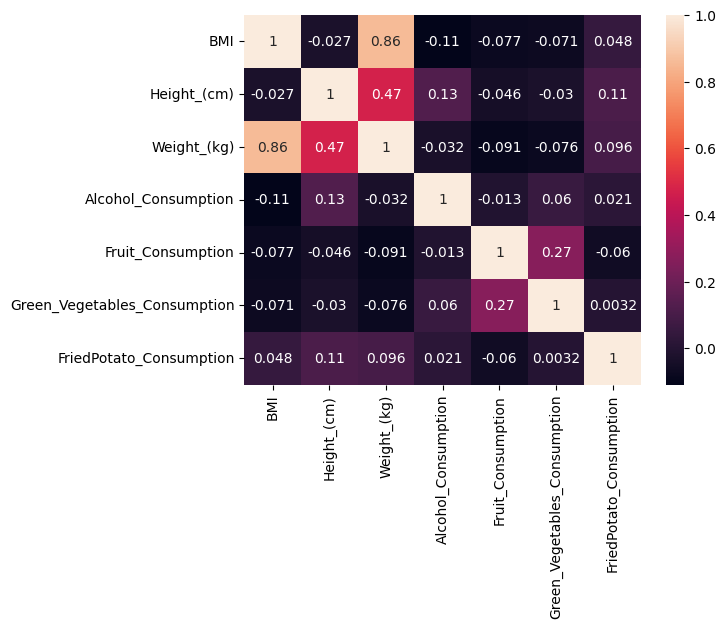

In [61]:
# plt.figure(figsize=(10,10))
numerical_columns = ['BMI', 'Height_(cm)', 'Weight_(kg)', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']
df_re = df[numerical_columns]
df_re = df_re.corr()
sns.heatmap(df_re,annot = True)
plt.show()

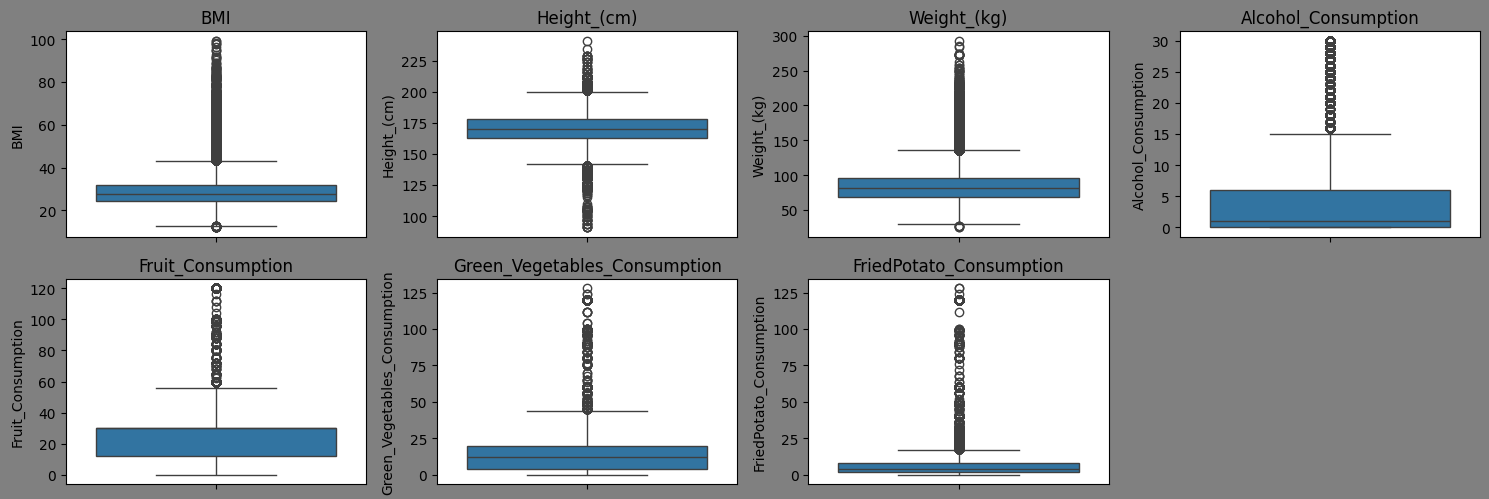

In [62]:
numerical_columns = ['BMI', 'Height_(cm)', 'Weight_(kg)', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']

plt.figure(figsize=(15, 10),facecolor='gray')

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(4, 4, i) 
    sns.boxplot(data=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

In [63]:
for col in numerical_columns:
    if df[col].dtype in [np.float64, np.int64]: 
        Q1=df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df[col] = np.where(df[col] < lower_bound, lower_bound,
                           np.where(df[col] > upper_bound, upper_bound, df[col]))

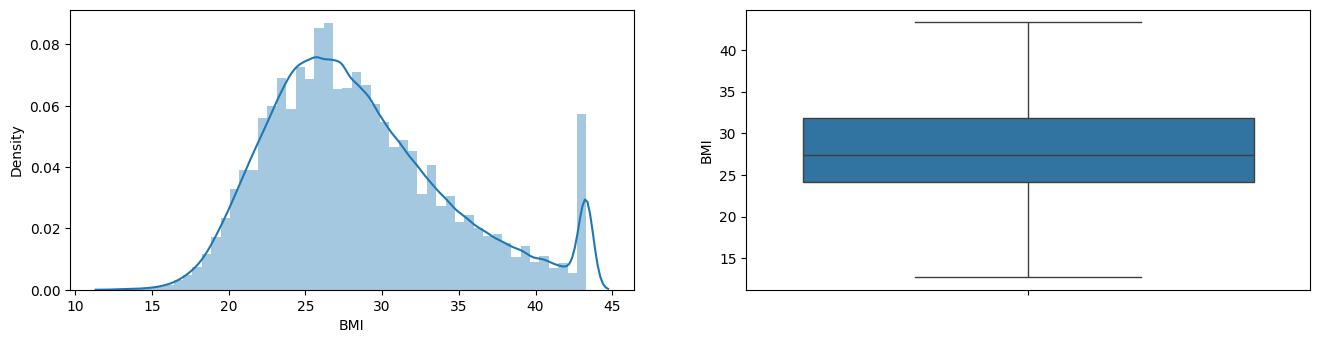

In [64]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['BMI'])

plt.subplot(2,2,2)
sns.boxplot(df['BMI'])
plt.show()

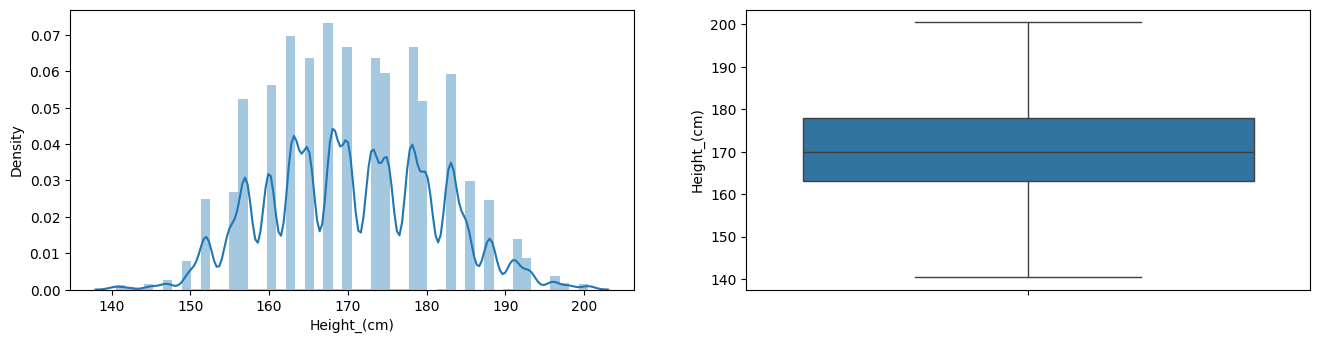

In [65]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['Height_(cm)'])

plt.subplot(2,2,2)
sns.boxplot(df['Height_(cm)'])
plt.show()

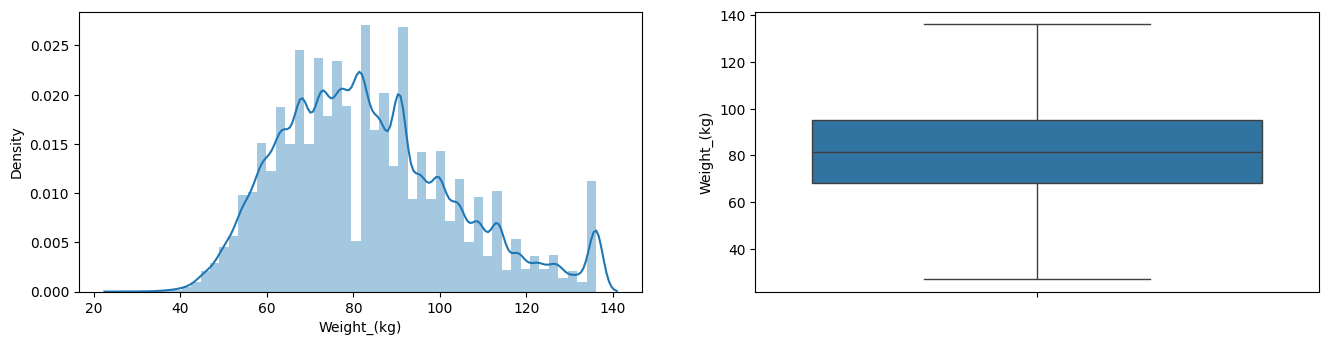

In [66]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['Weight_(kg)'])

plt.subplot(2,2,2)
sns.boxplot(df['Weight_(kg)'])
plt.show()

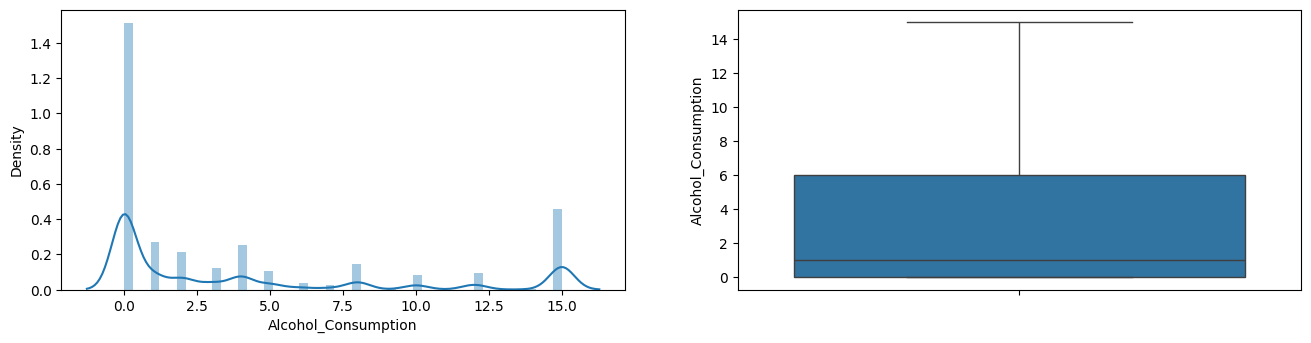

In [67]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['Alcohol_Consumption'])

plt.subplot(2,2,2)
sns.boxplot(df['Alcohol_Consumption'])
plt.show()

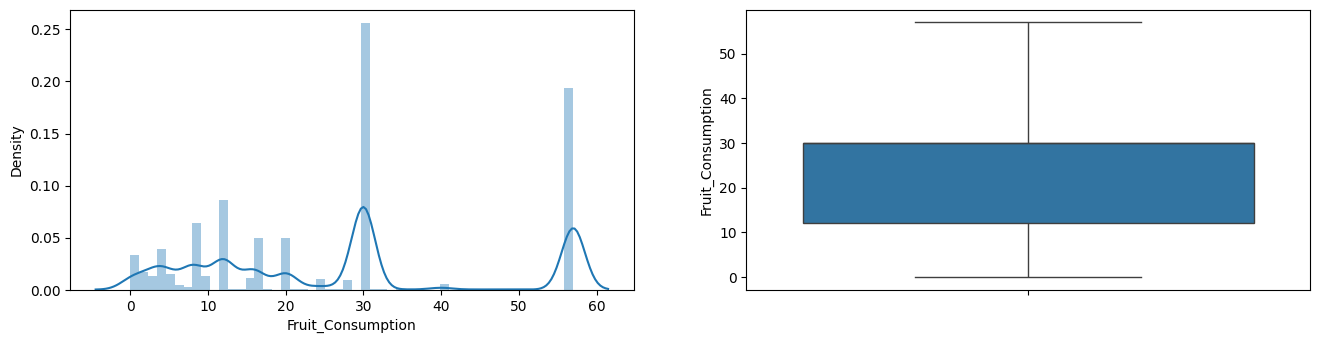

In [68]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['Fruit_Consumption'])

plt.subplot(2,2,2)
sns.boxplot(df['Fruit_Consumption'])
plt.show()

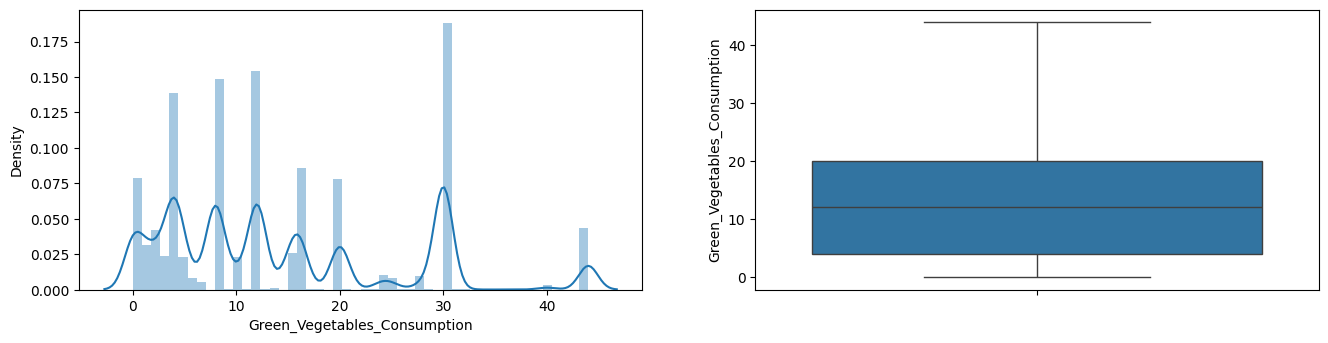

In [69]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['Green_Vegetables_Consumption'])

plt.subplot(2,2,2)
sns.boxplot(df['Green_Vegetables_Consumption'])
plt.show()

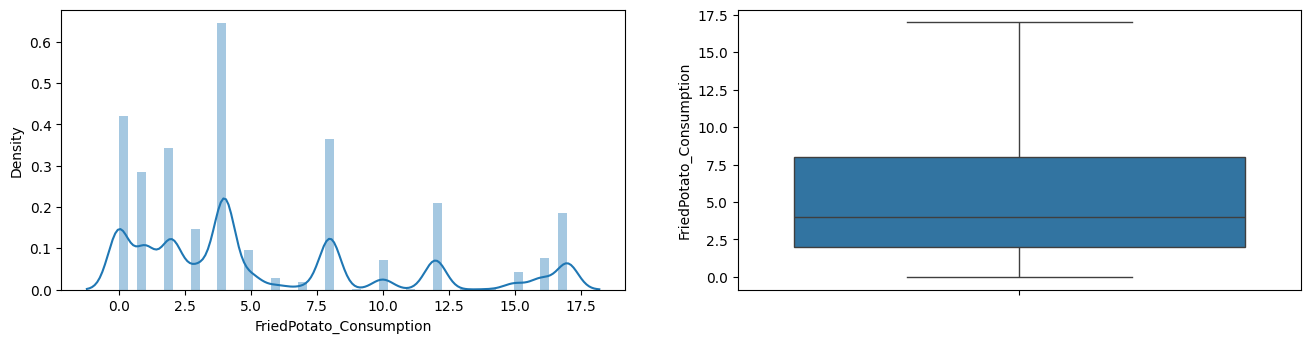

In [70]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['FriedPotato_Consumption'])

plt.subplot(2,2,2)
sns.boxplot(df['FriedPotato_Consumption'])
plt.show()

In [71]:
for col in numerical_columns:
    if df[col].dtype in [np.float64, np.int64]: 
     skew_value = df[col].skew()
     print (col,":",skew_value)

BMI : 0.6612686074279398
Height_(cm) : 0.07211633428684869
Weight_(kg) : 0.5930360469988403
Alcohol_Consumption : 1.1783280162865257
Fruit_Consumption : 0.4664874402669598
Green_Vegetables_Consumption : 0.8303745839797047
FriedPotato_Consumption : 0.9981019750930239


In [72]:
df.drop(['BMI'],axis=1,inplace=True)

In [73]:
df.drop(['Weight_(kg)'],axis=1,inplace=True)

In [121]:
df.drop(['Height_(cm)'],axis=1,inplace=True)

In [169]:
from sklearn.preprocessing import LabelEncoder

binary_cols = [
    'Exercise',
    'Heart_Disease',
    'Skin_Cancer',
    'Other_Cancer',
    'Depression',
    'Diabetes',
    'Arthritis',
    'Sex',
    'Smoking_History'
]

label_encoders = {}

for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [170]:
ordinal_cols = ['General_Health', 'Checkup', 'Age_Category']
ord_enc = OrdinalEncoder()
df[ordinal_cols] = ord_enc.fit_transform(df[ordinal_cols])

In [171]:
df

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,3.0,1.0,1,0,0,0,1,0,0,1,0.0,1,0.0,30.0,30.0,17.0
1,3.0,1.0,0,0,0,0,1,0,0,0,0.0,0,1.0,0.0,0.0,8.0
2,3.0,1.0,1,0,0,0,1,1,1,1,0.0,0,0.0,30.0,1.0,8.0
3,3.0,1.0,1,0,0,0,0,0,0,1,0.0,0,2.0,57.0,10.0,8.0
4,3.0,1.0,1,0,0,0,1,0,0,1,1.0,0,0.0,30.0,30.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308765,0.0,4.0,1,0,0,0,0,0,0,0,12.0,0,0.0,57.0,44.0,0.0
308766,0.0,4.0,1,0,0,0,0,0,0,0,12.0,0,2.0,30.0,0.0,0.0
308767,0.0,4.0,1,0,0,0,0,1,0,1,12.0,0,0.0,30.0,12.0,4.0
308768,0.0,4.0,1,0,0,0,0,0,0,1,12.0,0,1.0,30.0,12.0,1.0


In [172]:
vif_data = pd.DataFrame()
vif_data['Feature'] = df.columns
vif_data['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]

print(vif_data)

                         Feature       VIF
0                 General_Health  3.132450
1                        Checkup  8.938782
2                       Exercise  4.330296
3                  Heart_Disease  1.197748
4                    Skin_Cancer  1.208444
5                   Other_Cancer  1.188906
6                     Depression  1.328312
7                       Diabetes  1.294712
8                      Arthritis  1.821704
9                            Sex  2.051138
10                  Age_Category  6.034961
11               Smoking_History  1.781724
12           Alcohol_Consumption  1.639397
13             Fruit_Consumption  3.351106
14  Green_Vegetables_Consumption  2.808311
15       FriedPotato_Consumption  2.156448


In [173]:
print(df.columns.tolist())
print(df.shape)


['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Smoking_History', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']
(308770, 16)


In [174]:
scaler = StandardScaler()

In [175]:
x = df.drop('Heart_Disease', axis=1)
y = df['Heart_Disease']

In [176]:
x_scaled = scaler.fit_transform(x)

In [177]:
x_scaled

array([[ 0.48645717, -2.46649681,  0.53878463, ...,  0.16480043,
         1.37931558,  2.29010426],
       [ 0.48645717, -2.46649681, -1.85602918, ..., -1.43812584,
        -1.23236175,  0.50636294],
       [ 0.48645717, -2.46649681,  0.53878463, ...,  0.16480043,
        -1.14530584,  0.50636294],
       ...,
       [-1.52154677,  0.47568268,  0.53878463, ...,  0.16480043,
        -0.18769082, -0.28641099],
       [-1.52154677,  0.47568268,  0.53878463, ...,  0.16480043,
        -0.18769082, -0.88099143],
       [-1.52154677,  0.47568268,  0.53878463, ...,  1.60743407,
        -1.23236175, -0.88099143]], shape=(308770, 15))

In [178]:
x_train,x_test,y_train,y_test = train_test_split(x_scaled,y,test_size = 0.3,random_state = 33)

# LogisticRegression

In [179]:
lr = LogisticRegression()

In [180]:
lr.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [181]:
y_train_pred = lr.predict(x_train)

In [182]:
y_test_pred = lr.predict(x_test)

In [183]:
accuracy_score(y_train, y_train_pred)

0.9188716520387343

In [184]:
accuracy_score(y_test, y_test_pred)

0.9186125595103152

In [185]:
pd.DataFrame(classification_report(y_test,y_test_pred,output_dict = True))

,0,1,accuracy,macro avg,weighted avg
precision,0.920956,0.442731,0.918613,0.681844,0.882303
recall,0.997029,0.026847,0.918613,0.511938,0.918613
f1-score,0.957484,0.050623,0.918613,0.504054,0.884186
support,85144.000000,7487.000000,0.918613,92631.000000,92631.000000


In [186]:
confusion_matrix(y_test,y_test_pred)

array([[84891,   253],
       [ 7286,   201]])

In [187]:
presion=85010/(85010+208)
presion

0.9975592011077472

In [188]:
recall = 85010/(85010+7206)
recall

0.9218573783291403

In [189]:
f1 = 2*(presion*recall)/(presion+recall)
f1

0.9582154491247451

# K Nearest Neighbors

In [190]:
knn = KNeighborsClassifier()

In [191]:
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [192]:
y_train_pred_knn = knn.predict(x_train)

In [193]:
y_test_pred_knn = knn.predict(x_test)

In [194]:
accuracy_score(y_test,y_test_pred_knn)

0.9089073852166122

In [195]:
accuracy_score(y_train,y_train_pred_knn)

0.9265565214977399

In [196]:
pd.DataFrame(classification_report(y_test,y_test_pred_knn,output_dict = True))

,0,1,accuracy,macro avg,weighted avg
precision,0.924494,0.291539,0.908907,0.608016,0.873334
recall,0.981020,0.088821,0.908907,0.534921,0.908907
f1-score,0.951919,0.136159,0.908907,0.544039,0.885984
support,85144.000000,7487.000000,0.908907,92631.000000,92631.000000


# Decision Tree

In [197]:
DTree = DecisionTreeClassifier(
    max_depth=5,               # Limit depth
    min_samples_split=10,      # Require more samples to split
    min_samples_leaf=5,        # Leaves must have at least 5 samples
    random_state=42
)

In [198]:
DTree.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [199]:
y_train_pred_Dtree = DTree.predict(x_train)

In [200]:
y_test_pred_Dtree = DTree.predict(x_test)

In [201]:
accuracy_score(y_train,y_train_pred_Dtree)

0.9195147567074892

In [202]:
accuracy_score(y_test,y_test_pred_Dtree)

0.9194222236616252

In [203]:
pd.DataFrame(classification_report(y_test,y_test_pred_Dtree,output_dict = True))

,0,1,accuracy,macro avg,weighted avg
precision,0.921222,0.527187,0.919422,0.724204,0.889373
recall,0.997651,0.029785,0.919422,0.513718,0.919422
f1-score,0.957914,0.056384,0.919422,0.507149,0.885047
support,85144.000000,7487.000000,0.919422,92631.000000,92631.000000


# Random Forest

In [204]:
RFC = RandomForestClassifier(max_depth=10, n_estimators=100, min_samples_leaf=5)

In [205]:
RFC.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [206]:
y_test_pred_RF = RFC.predict(x_test)

In [207]:
y_train_pred_RF = RFC.predict(x_train)

In [208]:
accuracy_score(y_test,y_test_pred_RF)

0.9191847221772409

In [215]:
accuracy_score(y_train,y_train_pred_RF)

0.9192649174836564

In [216]:
pd.DataFrame(classification_report(y_test,y_test_pred_RF,output_dict = True))

,0,1,accuracy,macro avg,weighted avg
precision,0.919247,0.533333,0.919185,0.726290,0.888055
recall,0.999918,0.001069,0.919185,0.500493,0.919185
f1-score,0.957887,0.002133,0.919185,0.480010,0.880637
support,85144.000000,7487.000000,0.919185,92631.000000,92631.000000


In [221]:
joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [222]:
joblib.dump(ord_enc, "ordinal_encoder.pkl")

['ordinal_encoder.pkl']

In [223]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [220]:
joblib.dump(knn, 'cardiovascular_model.pkl')

['cardiovascular_model.pkl']